# Phantom Fairness: the fairness illusion created by label noise

### Part 2 of 3 - Linear heads, subgroup fairness, and the empirical anatomy of phantom fairness

This part trains the classifiers, measures subgroup fairness under three label regimes, and quantifies the group-dependent label noise that, we argue, manufactures the appearance of fairness.

#### Theoretical spine (what makes the result more than a benchmark)

The decisive prior result is Wang, Liu, and Levy (2021), *Fair Classification with Group-Dependent Label Noise*. Their Lemma 1 states that, for a subgroup `z` with group-dependent flip rates, the true-positive and false-positive rates measured against **noisy** labels relate to the rates against **clean** labels by

$$\widetilde{\mathrm{TPR}}_z \;=\; (1-\varepsilon_z^{+})\,\mathrm{TPR}_z \;+\; \varepsilon_z^{-}\,\mathrm{FPR}_z, \qquad \widetilde{\mathrm{FPR}}_z \;=\; \varepsilon_z^{+}\,\mathrm{TPR}_z \;+\; (1-\varepsilon_z^{-})\,\mathrm{FPR}_z,$$

where `ε_z^+` is the rate at which true positives are flipped to negative in the labels of group `z`, and `ε_z^-` the rate at which true negatives are flipped to positive. Their corollary is that a classifier can satisfy a fairness criterion on the noisy labels while violating it on the clean labels whenever the flip rates differ across groups. They call this a false impression of fairness.

Wang et al. prove this; they do not measure it in clinical data. This study does. We treat the NIH NLP labels as the noisy regime, the radiologist-adjudicated NIH labels (Majkowska et al., 2020) and the manually labelled PadChest samples (Bustos et al., 2020) as the clean regime, and we estimate `ε_z^+` and `ε_z^-` directly per subgroup rather than assuming them. The phantom-fairness effect is then the empirical gap between fairness measured on the noisy regime and the same predictions scored on the clean regime, decomposed through the equations above.

#### Methods anchors used in this part
Equal opportunity and equalised odds (Hardt, Price, and Srebro, 2016); demographic parity and disparate impact (Feldman et al., 2015); expected calibration error and reliability (Naeini et al., 2015; Guo et al., 2017); the incompatibility of calibration with equalised odds at unequal base rates (Pleiss et al., 2017); AUROC variance and comparison (DeLong et al., 1988; fast computation, Sun and Xu, 2014); directional bias amplification (Zhao et al., 2017; Wang and Russakovsky, 2021); and the CXR fairness backdrop (Larrazabal et al., 2020; Seyyed-Kalantari et al., 2021; Glocker et al., 2023). Frozen-embedding plus linear-head probing of fairness follows recent foundation-model fairness practice in medical imaging.

## Confirmatory hypotheses addressed in Part 2

| ID | Statement | Where tested |
|----|-----------|--------------|
| H1 | On the NLP regime, subgroup gaps (TPR, AUROC) are small. | Section 6 |
| H2 | NIH label noise is group-dependent: `ε_z^+` (missed positives) differs across subgroups, elevated for elderly women. | Section 7 |
| H3 | The same predictions show wider subgroup gaps on the clean regime than on the NLP regime (paired, same images). | Section 6 |
| H-amp | The model amplifies, rather than merely inherits, subgroup disparity present in the clean labels. | Section 10 |

Every estimate carries a stratified bootstrap 95% interval; paired regime comparisons use a paired bootstrap over the shared images; AUROC subgroup comparisons add a DeLong check; label-noise discordance uses McNemar; and the false discovery rate is controlled within each hypothesis family (Benjamini and Hochberg, 1995). Findings without an NLP counterpart (Fracture) are handled as a separate structural-noise case study (Section 13), because for them `ε^+ = 1` by construction.

---
## 0. Rehydrate Part 1 state

Part 2 is runnable on a fresh kernel. This section reconstructs the configuration, the master frames, and the embedding machinery from the artefacts Part 1 cached. If Part 1 has already run in this kernel, the in-memory frames are reused; otherwise the master frames are rebuilt from the cached image index and the label files, then saved to Parquet so subsequent reloads are instant. Run Part 1 at least once first so the caches exist.

In [24]:
import os, re, json, time, hashlib, logging, warnings, platform, importlib
from pathlib import Path
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple, Callable
import numpy as np, pandas as pd
import matplotlib, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

@dataclass
class Config:
    nih_root: str = r"C:\Users\kruta\Downloads\NIH Chest X-rays"
    padchest_root: str = r"C:\Users\kruta\Downloads\PadChest Chest X-rays (sample)"
    nih_labels_name: str = "Data_Entry_2017.csv"
    nih_google_name: str = "google2019_nih-chest-xray-labels.csv.gz"
    nih_google_raw_val: str = "four_findings_expert_labels_validation_labels.csv"
    nih_google_raw_test: str = "four_findings_expert_labels_test_labels.csv"
    padchest_labels_name: str = "chest_x_ray_images_labels_sample.csv"
    padchest_image_subdir: str = "sample"
    nih_image_subdirs_glob: str = "images_*"
    project_dir: str = str(Path.cwd() / "phantom_fairness")
    canonical_findings: Tuple[str, ...] = ("Airspace opacity","Pneumothorax","Nodule or mass","Fracture")
    age_bands: Tuple[Tuple[str,float,float], ...] = (("<40",0.0,40.0),("40-60",40.0,60.0),(">60",60.0,200.0))
    elderly_age_threshold: float = 60.0
    embedding_backbones: Tuple[str, ...] = ("xrv_densenet121","resnet50_imagenet","clip_vitb32")
    primary_backbone: str = "xrv_densenet121"
    embed_batch_size: int = 32
    embed_image_size: int = 224
    l2_normalise_embeddings: bool = False
    random_seed: int = 1997
    cpu_threads: int = max(1,(os.cpu_count() or 4)-1)
    # Part 2 specific
    max_train_images: int = 20000     # cap NLP training pool for CPU tractability
    n_bootstrap: int = 5000           # raise to 5000 for the final manuscript run
    n_calib_bins: int = 12
    strict_paths: bool = False
    @property
    def nih_labels_path(self): return Path(self.nih_root)/self.nih_labels_name
    @property
    def nih_google_path(self): return Path(self.nih_root)/self.nih_google_name
    @property
    def padchest_labels_path(self): return Path(self.padchest_root)/self.padchest_labels_name
    @property
    def padchest_image_dir(self): return Path(self.padchest_root)/self.padchest_image_subdir
    @property
    def out(self): return Path(self.project_dir)
    @property
    def cache_dir(self): return self.out/"cache"
    @property
    def emb_dir(self): return self.out/"embeddings"
    @property
    def fig_dir(self): return self.out/"figures"
    @property
    def tab_dir(self): return self.out/"tables"
    @property
    def prov_dir(self): return self.out/"provenance"

CFG = Config()
for d in (CFG.out,CFG.cache_dir,CFG.emb_dir,CFG.fig_dir,CFG.tab_dir,CFG.prov_dir): d.mkdir(parents=True,exist_ok=True)

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s", datefmt="%H:%M:%S")
log = logging.getLogger("phantom")
import random as _random
os.environ["PYTHONHASHSEED"]=str(CFG.random_seed); _random.seed(CFG.random_seed); np.random.seed(CFG.random_seed)
try:
    import torch; torch.manual_seed(CFG.random_seed); torch.set_num_threads(int(CFG.cpu_threads))
except Exception as e:
    log.warning("torch import deferred: %s", e)
plt.rcParams.update({"figure.dpi":110,"savefig.dpi":200,"font.size":10,"axes.grid":True,
                     "grid.alpha":0.25,"axes.spines.top":False,"axes.spines.right":False,"figure.autolayout":True})

def sha256_text(t): return hashlib.sha256(t.encode("utf-8")).hexdigest()
print("Config and runtime ready. Project:", CFG.out)

Config and runtime ready. Project: C:\Users\kruta\Downloads\phantom_fairness


In [25]:
# --- Condensed Part 1 loaders (used only if masters are not already in memory) ---
NIH14 = ["Atelectasis","Cardiomegaly","Effusion","Infiltration","Mass","Nodule","Pneumonia",
         "Pneumothorax","Consolidation","Edema","Emphysema","Fibrosis","Pleural_Thickening","Hernia"]
NIH_TO_CANON_TIGHT = {"Airspace opacity":["Infiltration","Consolidation"],"Pneumothorax":["Pneumothorax"],
                      "Nodule or mass":["Nodule","Mass"],"Fracture":[]}
GOOGLE_COL_SYNONYMS = {"Airspace opacity":["Airspace opacity","Airspace_Opacity","Lung Opacity","Lung_Opacity","opacity"],
                       "Pneumothorax":["Pneumothorax","pneumothorax"],
                       "Nodule or mass":["Nodule or mass","Nodule/mass","Nodule_or_mass","nodule/mass"],
                       "Fracture":["Fracture","fracture"]}
PADCHEST_TERM_MAP = {"Airspace opacity":["infiltrates","alveolar pattern","consolidation","pneumonia","air bronchogram",
                       "increased density","atypical pneumonia","interstitial pattern","ground glass pattern"],
                     "Pneumothorax":["pneumothorax","hydropneumothorax"],
                     "Nodule or mass":["nodule","multiple nodules","mass","pulmonary mass","lung mass","pseudonodule"],
                     "Fracture":["fracture","rib fracture","clavicle fracture","humeral fracture","vertebral fracture","callus rib fracture"]}
_YES={"YES","Y","1","1.0","TRUE","T","POSITIVE"}; _NO={"NO","N","0","0.0","FALSE","F","NEGATIVE",""}

def _parse_age(v):
    if pd.isna(v): return np.nan
    s=str(v).strip().upper(); m=re.match(r"^(\d+(?:\.\d+)?)\s*([YMD]?)$",s)
    if not m:
        d=re.sub(r"[^0-9.]","",s); 
        if d=="": return np.nan
        y=float(d)
    else:
        y=float(m.group(1)); u=m.group(2) or "Y"
        if u=="M": y/=12.0
        elif u=="D": y/=365.25
    return np.nan if (y<=0 or y>120) else y

def _to01(s):
    def c(v):
        if pd.isna(v): return np.nan
        t=str(v).strip().upper()
        if t in _YES: return 1
        if t in _NO: return 0
        try: return 1 if float(t)>=0.5 else 0
        except: return np.nan
    return s.map(c)

def _stdkey(df):
    for c in ["Image Index","image_id","ImageID","Image","filename","image"]:
        if c in df.columns: df=df.rename(columns={c:"Image Index"}); break
    df["Image Index"]=df["Image Index"].astype(str).str.strip()
    df["Image Index"]=df["Image Index"].apply(lambda s:s if s.lower().endswith(".png") else s+".png")
    return df

def rebuild_masters(cfg):
    idx_cache=cfg.cache_dir/"nih_image_index.parquet"
    if not idx_cache.exists(): raise FileNotFoundError("Run Part 1 first (nih_image_index.parquet missing).")
    nih_index=pd.read_parquet(idx_cache)
    # NIH NLP labels
    d=pd.read_csv(cfg.nih_labels_path).rename(columns={"Patient Age":"age_raw","Patient Gender":"sex",
        "View Position":"view","Patient ID":"patient_id"})
    fl=d["Finding Labels"].fillna("").str.split("|")
    for f in NIH14: d["nih_"+f]=fl.apply(lambda l,f=f:int(f in l))
    d["age"]=d["age_raw"].apply(_parse_age); d["sex"]=d["sex"].astype(str).str.upper().str[0].map({"M":"M","F":"F"})
    d["view"]=d["view"].astype(str).str.upper().str.strip()
    nih_lab=d[["Image Index","patient_id","age","sex","view"]+["nih_"+f for f in NIH14]].copy()
    # canonical NLP projection
    nc=nih_lab[["Image Index"]].copy()
    for canon,src in NIH_TO_CANON_TIGHT.items():
        cols=["nih_"+s for s in src if ("nih_"+s) in nih_lab.columns]
        nc["nlp_"+canon]=(nih_lab[cols].sum(axis=1)>0).astype(int) if cols else 0
    # adjudicated
    frames=[]
    if cfg.nih_google_path.exists():
        g=_stdkey(pd.read_csv(cfg.nih_google_path)); frames.append(g)
    for nm in [cfg.nih_google_raw_val,cfg.nih_google_raw_test]:
        p=Path(cfg.nih_root)/nm
        if p.exists(): frames.append(_stdkey(pd.read_csv(p)))
    if frames:
        gg=pd.concat(frames,ignore_index=True); out=pd.DataFrame({"Image Index":gg["Image Index"]})
        for canon,syns in GOOGLE_COL_SYNONYMS.items():
            col=next((s for s in syns if s in gg.columns),None)
            out["adj_"+canon]=_to01(gg[col]) if col is not None else np.nan
        agg={c:"first" for c in out.columns if c!="Image Index"}
        nih_google=out.groupby("Image Index",as_index=False).agg(agg)
    else:
        nih_google=pd.DataFrame(columns=["Image Index"])
    m=nih_index.merge(nih_lab,on="Image Index",how="inner").merge(nc,on="Image Index",how="left")
    if len(nih_google)>1: m=m.merge(nih_google,on="Image Index",how="left")
    adj_cols=[c for c in m.columns if c.startswith("adj_")]
    m["has_adjudicated"]=m[adj_cols].notna().any(axis=1) if adj_cols else False
    m=_assign_subgroups(m,cfg)
    # PadChest
    pc=pd.DataFrame()
    if cfg.padchest_labels_path.exists() and cfg.padchest_image_dir.exists():
        try: pdf=pd.read_csv(cfg.padchest_labels_path)
        except Exception: pdf=pd.read_excel(cfg.padchest_labels_path)
        if "ImageID" not in pdf.columns:
            for c in ["Image Index","image_id","filename"]:
                if c in pdf.columns: pdf=pdf.rename(columns={c:"ImageID"}); break
        pdf["ImageID"]=pdf["ImageID"].astype(str).str.strip()
        pdf["sex"]=pdf.get("PatientSex_DICOM",pd.Series(np.nan,index=pdf.index)).astype(str).str.upper().str[0].map({"M":"M","F":"F"})
        birth=pd.to_numeric(pdf.get("PatientBirth"),errors="coerce")
        sy=pd.to_numeric(pdf.get("StudyDate_DICOM",pd.Series(np.nan,index=pdf.index)).astype(str).str[:4],errors="coerce")
        pdf["age"]=(sy-birth).where(lambda s:(s>0)&(s<=120))
        proj=pdf.get("Projection",pdf.get("ViewPosition_DICOM"))
        proj=proj.astype(str).str.upper().str.strip() if proj is not None else pd.Series("",index=pdf.index)
        pdf["view"]=proj.where(proj.isin(["PA","AP"]),other="OTHER")
        def parse(c):
            if pd.isna(c): return []
            return [p.strip().strip("'").strip('"').lower() for p in re.split(r"[,;]",str(c).strip("[]")) if p.strip().strip("'").strip('"').lower() not in ("","nan","normal")]
        terms=pdf.get("Labels",pd.Series([""]*len(pdf))).apply(parse)
        for canon,tl in PADCHEST_TERM_MAP.items():
            ts=set(t.lower() for t in tl)
            pdf["pc_"+canon]=terms.apply(lambda lst,ts=ts:int(any(any(t in it for t in ts) for it in lst)))
        imgs=pd.DataFrame([{"ImageID":p.name,"image_path":str(p)} for p in cfg.padchest_image_dir.glob("*.png")])
        pc=imgs.merge(pdf,on="ImageID",how="inner"); pc=_assign_subgroups(pc,cfg)
    return m, pc

def _assign_subgroups(df,cfg):
    out=df.copy()
    def band(a):
        if pd.isna(a): return "unknown"
        for n,lo,hi in cfg.age_bands:
            if lo<=a<hi: return n
        return "unknown"
    out["age_band"]=out["age"].apply(band); out["sex"]=out["sex"].fillna("unknown")
    out["view"]=out.get("view",pd.Series("unknown",index=out.index)).fillna("unknown")
    out["elderly_women"]=((out["sex"]=="F")&(out["age"]>cfg.elderly_age_threshold)).map({True:"F>60",False:"other"})
    return out
print("Condensed loaders defined.")

Condensed loaders defined.


In [26]:
# ============================================================
# SAFE MASTER-FRAME LOADING WITH PADCHEST OVERFLOW FIX
# ============================================================

def safe_cast_padchest(df: pd.DataFrame) -> pd.DataFrame:
    """
    Fixes OverflowError when saving PadChest to Parquet by:
    - Converting huge int columns to string
    - Dropping irrelevant DICOM metadata columns
    - Ensuring all UID/date fields are strings
    """
    if df is None or not len(df):
        return df

    df = df.copy()

    # Columns that often break PyArrow on Windows
    drop_cols = [
        "StudyInstanceUID", "SeriesInstanceUID", "SOPInstanceUID",
        "AccessionNumber", "StudyID", "SeriesNumber", "InstanceNumber",
        "PatientBirth", "StudyDate_DICOM", "SeriesDate_DICOM",
        "AcquisitionDate_DICOM", "ContentDate_DICOM"
    ]

    for col in drop_cols:
        if col in df.columns:
            df.drop(columns=[col], inplace=True, errors="ignore")

    # Convert any remaining large ints to strings
    for col in df.columns:
        if df[col].dtype == "int64":
            # If values exceed int64 range, convert to string
            if df[col].max() > 2**63 - 1:
                df[col] = df[col].astype(str)

        # Convert float columns with NaN to float32 (Arrow-safe)
        if df[col].dtype == "float64" and df[col].isna().any():
            df[col] = df[col].astype("float32")

    return df


# ============================================================
# MASTER FRAME ACQUISITION LOGIC (REPLACEMENT BLOCK)
# ============================================================

_mn = CFG.cache_dir / "master_nih.parquet"
_mp = CFG.cache_dir / "master_padchest.parquet"

if (
    "nih_master" in globals()
    and isinstance(globals().get("nih_master"), pd.DataFrame)
    and len(globals()["nih_master"])
):
    log.info("Reusing in-memory masters from Part 1.")

    nih_master = globals()["nih_master"]
    padchest_master = globals().get("padchest_master", pd.DataFrame())

    # Save NIH master safely
    try:
        nih_master.to_parquet(_mn, index=False)
    except Exception as e:
        log.warning("Could not cache NIH master: %s", e)

    # Save PadChest master safely
    if len(padchest_master):
        try:
            pc_safe = safe_cast_padchest(padchest_master)
            pc_safe.to_parquet(_mp, index=False)
        except Exception as e:
            log.warning("Could not cache PadChest master: %s", e)

elif _mn.exists():
    # Load cached masters
    nih_master = pd.read_parquet(_mn)

    if _mp.exists():
        try:
            padchest_master = pd.read_parquet(_mp)
        except Exception as e:
            log.warning("PadChest cache unreadable (%s). Rebuilding PadChest.", e)
            _, padchest_master = rebuild_masters(CFG)
    else:
        padchest_master = pd.DataFrame()

    log.info("Loaded masters from Parquet cache.")

else:
    # Rebuild from raw data
    nih_master, padchest_master = rebuild_masters(CFG)

    # Save NIH master
    try:
        nih_master.to_parquet(_mn, index=False)
    except Exception as e:
        log.warning("Could not save NIH master: %s", e)

    # Save PadChest master safely
    if len(padchest_master):
        try:
            pc_safe = safe_cast_padchest(padchest_master)
            pc_safe.to_parquet(_mp, index=False)
        except Exception as e:
            log.warning("Could not save PadChest master: %s", e)

    log.info("Rebuilt masters from source and cached.")

print(
    "NIH master:", len(nih_master),
    "| with adjudicated:", int(nih_master["has_adjudicated"].sum()) if "has_adjudicated" in nih_master else 0,
    "| PadChest:", len(padchest_master)
)


14:47:37 [INFO] Reusing in-memory masters from Part 1.


NIH master: 112120 | with adjudicated: 4376 | PadChest: 24


In [27]:
# --- Backbone registry + cache-aware extractor (ported from Part 1) ---
from PIL import Image
def _try_import(n):
    try: return importlib.import_module(n)
    except Exception as e: log.info("optional import %s: %s", n, e); return None

class Backbone:
    name="base"; dim=None
    def preprocess(self,img): raise NotImplementedError
    def embed_batch(self,x): raise NotImplementedError
    def extract(self,paths,batch_size=32):
        import torch as T; feats=[]; buf=[]
        def flush():
            if not buf: return
            with T.no_grad(): f=self.embed_batch(T.stack(buf,0))
            feats.append(f.detach().cpu().numpy()); buf.clear()
        for p in paths:
            try: img=Image.open(p).convert("L")
            except Exception: img=Image.new("L",(CFG.embed_image_size,CFG.embed_image_size))
            buf.append(self.preprocess(img))
            if len(buf)>=batch_size: flush()
        flush()
        return np.concatenate(feats,0) if feats else np.zeros((0,self.dim or 1))

class XRVDenseNet(Backbone):
    name="xrv_densenet121"; dim=1024
    def __init__(self):
        self.xrv=importlib.import_module("torchxrayvision"); self.T=importlib.import_module("torch")
        self.tv=importlib.import_module("torchvision")
        self.model=self.xrv.models.DenseNet(weights="densenet121-res224-all").eval()
    def preprocess(self,img):
        a=self.xrv.datasets.normalize(np.asarray(img).astype(np.float32),255)[None,...]
        return self.tv.transforms.functional.resize(self.T.from_numpy(a),[224,224],antialias=True)
    def embed_batch(self,x): return self.model.features2(x)

class ResNet50(Backbone):
    name="resnet50_imagenet"; dim=2048
    def __init__(self):
        self.T=importlib.import_module("torch"); tv=importlib.import_module("torchvision")
        w=tv.models.ResNet50_Weights.IMAGENET1K_V2; m=tv.models.resnet50(weights=w); m.fc=self.T.nn.Identity()
        self.model=m.eval(); self.tf=w.transforms()
    def preprocess(self,img): return self.tf(img.convert("RGB"))
    def embed_batch(self,x): return self.model(x)

class CLIPViTB32(Backbone):
    name="clip_vitb32"; dim=512
    def __init__(self):
        self.T=importlib.import_module("torch"); oc=importlib.import_module("open_clip")
        self.model,_,self.pf=oc.create_model_and_transforms("ViT-B-32",pretrained="openai"); self.model=self.model.eval()
    def preprocess(self,img): return self.pf(img.convert("RGB"))
    def embed_batch(self,x): return self.model.encode_image(x)

REG={"xrv_densenet121":XRVDenseNet,"resnet50_imagenet":ResNet50,"clip_vitb32":CLIPViTB32}
def build_backbone(name):
    try:
        bb=REG[name](); log.info("Backbone ready: %s (dim=%s)",bb.name,bb.dim); return bb
    except Exception as e:
        import traceback; log.warning("Backbone %s unavailable: %s",name,e); log.info(traceback.format_exc()); return None

def _idhash(ids): return sha256_text("\u241f".join(map(str,ids)))
def extract_embeddings(tag, df, id_col, backbone_name, force=False):
    ids=df[id_col].astype(str).tolist(); paths=df["image_path"].tolist()
    npy=CFG.emb_dir/f"{tag}__{backbone_name}.npy"; idxp=CFG.emb_dir/f"{tag}__{backbone_name}__index.parquet"
    man=CFG.emb_dir/f"{tag}__{backbone_name}__manifest.json"; want=_idhash(ids)
    if (not force) and npy.exists() and man.exists():
        try:
            if json.loads(man.read_text()).get("id_hash")==want:
                e=np.load(npy); log.info("cache hit %s/%s %s",tag,backbone_name,e.shape); return e,pd.read_parquet(idxp)
        except Exception: pass
    bb=build_backbone(backbone_name)
    if bb is None: return None,pd.DataFrame()
    t0=time.time(); e=bb.extract(paths,CFG.embed_batch_size)
    if CFG.l2_normalise_embeddings and len(e): e=e/(np.linalg.norm(e,axis=1,keepdims=True)+1e-8)
    np.save(npy,e.astype(np.float32)); pd.DataFrame({"row":range(len(ids)),id_col:ids}).to_parquet(idxp,index=False)
    man.write_text(json.dumps({"tag":tag,"backbone":backbone_name,"n":len(ids),
        "dim":int(e.shape[1]) if e.ndim==2 and e.shape[0] else None,"id_hash":want,
        "seconds":round(time.time()-t0,2)},indent=2))
    log.info("extracted %s/%s %s in %.1fs",tag,backbone_name,e.shape,time.time()-t0)
    return e,pd.read_parquet(idxp)
print("Embedding machinery ready.")

Embedding machinery ready.


In [28]:
# === PATCH: make PadChest parquet-safe (drops DICOM ints that overflow int64) ===
def slim_padchest(pc, cfg):
    if pc is None or not len(pc): return pc
    keep = ["ImageID","image_path","sex","age","view","age_band","elderly_women"] \
           + ["pc_"+c for c in cfg.canonical_findings]
    keep = [c for c in keep if c in pc.columns]
    out = pc[keep].copy()
    for c in out.columns:
        if c == "age":            out[c] = pd.to_numeric(out[c], errors="coerce").astype("float64")
        elif c.startswith("pc_"): out[c] = pd.to_numeric(out[c], errors="coerce").fillna(0).astype("int8")
        else:                     out[c] = out[c].astype("string")
    return out

padchest_master = slim_padchest(padchest_master, CFG)
try:
    if len(padchest_master):
        padchest_master.to_parquet(CFG.cache_dir/"master_padchest.parquet", index=False)
        print("Saved slim PadChest:", padchest_master.shape, "->", list(padchest_master.columns))
    else:
        print("PadChest sample not present yet (only needed in Part 3).")
except Exception as e:
    print("PadChest cache skipped, continuing:", e)

# the counts the crashed cell never reached
n_adj = int(nih_master["has_adjudicated"].sum())
print(f"\nnih_master rows: {len(nih_master)} | with adjudicated labels: {n_adj}")
for canon in CFG.canonical_findings:
    a = "adj_"+canon
    if a in nih_master.columns:
        print(f"   {canon:16s}: positives = {int(np.nansum(nih_master[a].values))} / {int(nih_master[a].notna().sum())}")

Saved slim PadChest: (24, 11) -> ['ImageID', 'image_path', 'sex', 'age', 'view', 'age_band', 'elderly_women', 'pc_Airspace opacity', 'pc_Pneumothorax', 'pc_Nodule or mass', 'pc_Fracture']

nih_master rows: 112120 | with adjudicated labels: 4376
   Airspace opacity: positives = 2166 / 4376
   Pneumothorax    : positives = 238 / 4376
   Nodule or mass  : positives = 605 / 4376
   Fracture        : positives = 186 / 4376


---
## 1. Analysis cohort and patient-level split

Two rules protect the headline result from the usual objections.

First, **no patient leakage**. We split by `patient_id`. Every NIH patient that carries an adjudicated label is placed in the test set, so the clean labels are never seen during training. The remaining patients form the training and validation pools.

Second, the **paired clean-versus-noisy comparison is restricted to the same images**. The NLP-versus-adjudicated contrast (H1 and H3) is computed only on the adjudicated-labelled test images, so any difference in measured fairness is attributable to the label regime and not to a change of sample. The NLP training pool is capped at `max_train_images` for CPU tractability; enlarging it only tightens intervals and does not change the design.

In [29]:
from numpy.random import default_rng
rng = default_rng(CFG.random_seed)

def build_cohort(cfg, master):
    assert "patient_id" in master.columns, "patient_id required"
    adj_patients = set(master.loc[master["has_adjudicated"], "patient_id"].unique())
    is_test = master["patient_id"].isin(adj_patients)
    test = master[is_test].copy()
    pool = master[~is_test].copy()
    # patient-disjoint train/val from the pool
    pats = pool["patient_id"].unique(); rng.shuffle(pats)
    n_val = max(1, int(0.15*len(pats))); val_pats=set(pats[:n_val]); 
    val = pool[pool["patient_id"].isin(val_pats)].copy()
    train = pool[~pool["patient_id"].isin(val_pats)].copy()
    if cfg.max_train_images and len(train) > cfg.max_train_images:
        train = train.sample(cfg.max_train_images, random_state=cfg.random_seed).reset_index(drop=True)
    for name, fr in [("train",train),("val",val),("test",test)]:
        log.info("cohort %-5s images=%6d patients=%5d", name, len(fr), fr["patient_id"].nunique())
    # leakage assertion
    assert not (set(train["patient_id"]) & set(test["patient_id"])), "patient leakage train/test"
    assert not (set(val["patient_id"]) & set(test["patient_id"])), "patient leakage val/test"
    return train.reset_index(drop=True), val.reset_index(drop=True), test.reset_index(drop=True)

train_df, val_df, test_df = build_cohort(CFG, nih_master)
# the clean evaluation frame = test images that actually carry adjudicated labels
eval_clean = test_df[test_df["has_adjudicated"]].copy().reset_index(drop=True)
print("Clean-evaluation images (adjudicated, in test):", len(eval_clean))
for canon in CFG.canonical_findings:
    a="adj_"+canon
    if a in eval_clean.columns:
        print(f"  {canon:16s}: adjudicated positives = {int(np.nansum(eval_clean[a].values))} / {int(eval_clean[a].notna().sum())}")

14:47:38 [INFO] cohort train images= 20000 patients=10998
14:47:38 [INFO] cohort val   images= 12930 patients= 4366
14:47:38 [INFO] cohort test  images= 26921 patients= 1695


Clean-evaluation images (adjudicated, in test): 4376
  Airspace opacity: adjudicated positives = 2166 / 4376
  Pneumothorax    : adjudicated positives = 238 / 4376
  Nodule or mass  : adjudicated positives = 605 / 4376
  Fracture        : adjudicated positives = 186 / 4376


---
## 2. Frozen-embedding extraction for the cohort

Embeddings are produced once per backbone for the train, validation, and clean-evaluation frames and cached. The first call to each backbone downloads its weights, which is a one-time cost. On a CPU laptop the primary backbone (`xrv_densenet121`) is the fastest meaningful choice; the others support the ablation in Section 12.

In [30]:
def embed_frames(backbone_name):
    out={}
    for tag, fr, idc in [("train",train_df,"Image Index"),("val",val_df,"Image Index"),
                         ("evalclean",eval_clean,"Image Index")]:
        if not len(fr): out[tag]=(None,fr); continue
        e,idx=extract_embeddings(tag,fr,idc,backbone_name)
        out[tag]=(e,fr)
    return out

# Primary backbone now; ablation backbones are extracted lazily in Section 12.
EMB = {}
EMB[CFG.primary_backbone] = embed_frames(CFG.primary_backbone)
e_tr = EMB[CFG.primary_backbone]["train"][0]
print("Primary embeddings:", None if e_tr is None else e_tr.shape)
if e_tr is None:
    print("No embeddings produced. Confirm the phantom kernel is active and torch imports cleanly.")

14:47:39 [INFO] cache hit train/xrv_densenet121 (20000, 1024)
14:47:39 [INFO] cache hit val/xrv_densenet121 (12930, 1024)
14:47:39 [INFO] cache hit evalclean/xrv_densenet121 (4376, 1024)


Primary embeddings: (20000, 1024)


---
## 3. Linear heads trained on the NLP regime

We probe fairness with frozen embeddings and per-finding logistic heads, the standard light-weight foundation-model fairness setup. The heads are trained on the **NLP** labels, exactly as a real NIH-trained model would be, and the operating threshold is selected on a held-out validation split scored against **NLP** labels. This is deliberate: a model built in the ordinary way inherits the noisy labels at both fitting and thresholding. The clean labels are reserved entirely for evaluation.

`Fracture` is skipped here because it has no NLP positives to learn from; that degeneracy is the subject of the structural-noise case study in Section 13.

In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

NLP_FINDINGS = [f for f in CFG.canonical_findings if NIH_TO_CANON_TIGHT.get(f)]  # excludes Fracture
print("Findings modelled from NLP labels:", NLP_FINDINGS)

def youden_threshold(y, p):
    from sklearn.metrics import roc_curve
    if len(np.unique(y))<2: return 0.5
    fpr,tpr,thr=roc_curve(y,p); j=tpr-fpr; return float(thr[int(np.argmax(j))])

def train_heads(emb_pack, backbone_name):
    (Xtr, tr) = emb_pack["train"]; (Xva, va) = emb_pack["val"]; (Xev, ev) = emb_pack["evalclean"]
    if Xtr is None or Xev is None: 
        log.warning("Missing embeddings for %s", backbone_name); return None
    scaler = StandardScaler().fit(Xtr)
    Ztr, Zva, Zev = scaler.transform(Xtr), (scaler.transform(Xva) if Xva is not None else None), scaler.transform(Xev)
    heads, thresholds, scores_eval = {}, {}, {}
    for f in NLP_FINDINGS:
        ytr = tr["nlp_"+f].astype(int).values
        if ytr.sum() < 10:
            log.warning("Too few NLP positives for %s (%d); skipping", f, int(ytr.sum())); continue
        clf = LogisticRegression(C=1.0, class_weight="balanced", max_iter=2000, n_jobs=-1)
        clf.fit(Ztr, ytr)
        heads[f] = clf
        p_eval = clf.predict_proba(Zev)[:,1]; scores_eval[f] = p_eval
        if Zva is not None and ("nlp_"+f) in va.columns and va["nlp_"+f].nunique()>1:
            p_va = clf.predict_proba(Zva)[:,1]; thresholds[f] = youden_threshold(va["nlp_"+f].astype(int).values, p_va)
        else:
            thresholds[f] = 0.5
    return {"scaler":scaler,"heads":heads,"thresholds":thresholds,"scores_eval":scores_eval,"eval_frame":ev}

MODELS = {}
MODELS[CFG.primary_backbone] = train_heads(EMB[CFG.primary_backbone], CFG.primary_backbone)
if MODELS[CFG.primary_backbone]:
    print("Trained heads:", list(MODELS[CFG.primary_backbone]["heads"].keys()))
    print("Operating thresholds (tuned on NLP val):",
          {k: round(v,3) for k,v in MODELS[CFG.primary_backbone]["thresholds"].items()})

Findings modelled from NLP labels: ['Airspace opacity', 'Pneumothorax', 'Nodule or mass']
Trained heads: ['Airspace opacity', 'Pneumothorax', 'Nodule or mass']
Operating thresholds (tuned on NLP val): {'Airspace opacity': 0.474, 'Pneumothorax': 0.084, 'Nodule or mass': 0.537}


---
## 4. Metric and inference library

Everything downstream is built from this one cell so the statistics are auditable in a single place: AUROC with DeLong variance and intervals (DeLong et al., 1988; fast midrank computation, Sun and Xu, 2014), AUPRC, true and false positive rates, expected calibration error with both equal-width and equal-mass binning, the Brier score, the four fairness gaps (equal opportunity, equalised-odds, demographic parity, AUROC), a stratified bootstrap for any subgroup gap, a paired image-level bootstrap for the clean-versus-noisy regime difference, McNemar for label discordance, Benjamini-Hochberg false-discovery control, the directional bias-amplification metric (Wang and Russakovsky, 2021), and the Wang et al. (2021) group-dependent noise decomposition.

In [32]:
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from scipy import stats as sstats

# ---- AUROC variance via fast DeLong (single classifier) ----
def _midrank(x):
    J=np.argsort(x,kind="mergesort"); Z=x[J]; N=len(x); T=np.zeros(N); i=0
    while i<N:
        j=i
        while j<N and Z[j]==Z[i]: j+=1
        T[i:j]=0.5*(i+j-1)+1; i=j
    T2=np.empty(N); T2[J]=T; return T2

def delong_auc_var(y_true, y_score):
    y_true=np.asarray(y_true); y_score=np.asarray(y_score,dtype=float)
    pos=y_score[y_true==1]; neg=y_score[y_true==0]; m=len(pos); n=len(neg)
    if m==0 or n==0: return np.nan, np.nan
    tx=_midrank(pos); ty=_midrank(neg); tz=_midrank(np.concatenate([pos,neg]))
    auc=(tz[:m].sum()-m*(m+1)/2.0)/(m*n)
    v10=(tz[:m]-tx)/n                 # placement of each positive among negatives
    v01=1.0-(tz[m:]-ty)/m             # placement of each negative among positives
    s10=np.var(v10,ddof=1) if m>1 else 0.0
    s01=np.var(v01,ddof=1) if n>1 else 0.0
    return float(auc), float(s10/m + s01/n)

def auc_ci(y, p, alpha=0.05):
    a,v=delong_auc_var(y,p)
    if np.isnan(a) or v<=0: return a, np.nan, np.nan
    z=sstats.norm.ppf(1-alpha/2); se=np.sqrt(v)
    return a, max(0.0,a-z*se), min(1.0,a+z*se)

def delong_two_sample_z(y1,p1,y2,p2):
    a1,v1=delong_auc_var(y1,p1); a2,v2=delong_auc_var(y2,p2)
    if np.isnan(a1) or np.isnan(a2) or (v1+v2)<=0: return np.nan, np.nan
    z=(a1-a2)/np.sqrt(v1+v2); return float(z), float(2*(1-sstats.norm.cdf(abs(z))))

# ---- calibration ----
def ece(y, p, n_bins=12, strategy="uniform"):
    y=np.asarray(y); p=np.asarray(p,dtype=float)
    if len(y)==0: return np.nan
    if strategy=="quantile":
        edges=np.unique(np.quantile(p, np.linspace(0,1,n_bins+1)))
        if len(edges)<3: edges=np.linspace(0,1,n_bins+1)
    else:
        edges=np.linspace(0,1,n_bins+1)
    e=0.0; N=len(y)
    for lo,hi in zip(edges[:-1],edges[1:]):
        m=(p>lo)&(p<=hi) if lo>edges[0] else (p>=lo)&(p<=hi)
        if m.sum()==0: continue
        e += (m.sum()/N)*abs(y[m].mean()-p[m].mean())
    return float(e)

def brier(y,p): 
    y=np.asarray(y,dtype=float); p=np.asarray(p,dtype=float)
    return float(np.mean((p-y)**2)) if len(y) else np.nan

# ---- rate metrics ----
def tpr_fpr(y, yhat):
    y=np.asarray(y); yhat=np.asarray(yhat)
    P=(y==1); N=(y==0)
    tpr=float(yhat[P].mean()) if P.sum() else np.nan
    fpr=float(yhat[N].mean()) if N.sum() else np.nan
    return tpr,fpr
def selection_rate(yhat): 
    return float(np.asarray(yhat).mean()) if len(yhat) else np.nan

# ---- subgroup gap helpers ----
def group_values(df, groups_col, score, label, thr, metric):
    out={}
    for g,sub in df.groupby(groups_col):
        y=sub[label].astype(float).values; valid=~np.isnan(y)
        y=y[valid].astype(int); p=sub[score].values[valid]
        if len(y)==0: out[g]=np.nan; continue
        if metric=="auroc": out[g]=roc_auc_score(y,p) if len(np.unique(y))>1 else np.nan
        elif metric=="auprc": out[g]=average_precision_score(y,p) if y.sum()>0 else np.nan
        elif metric in ("tpr","fpr"):
            yhat=(p>=thr).astype(int); t,f=tpr_fpr(y,yhat); out[g]=t if metric=="tpr" else f
        elif metric=="selrate": out[g]=selection_rate((p>=thr).astype(int))
        else: out[g]=np.nan
    return out

def gap_from_groups(gv, min_n=None):
    vals=[v for v in gv.values() if v is not None and not (isinstance(v,float) and np.isnan(v))]
    if len(vals)<2: return np.nan
    return float(max(vals)-min(vals))

def equalized_odds_gap(df, groups_col, score, label, thr):
    t=gap_from_groups(group_values(df,groups_col,score,label,thr,"tpr"))
    f=gap_from_groups(group_values(df,groups_col,score,label,thr,"fpr"))
    vals=[x for x in [t,f] if not np.isnan(x)]
    return float(max(vals)) if vals else np.nan

# ---- bootstrap (stratified within subgroup) ----
def bootstrap_gap_ci(df, groups_col, score, label, thr, metric, n_boot=2000, seed=0, alpha=0.05):
    r=default_rng(seed); idx_by_g={g:sub.index.values for g,sub in df.groupby(groups_col)}
    point = gap_from_groups(group_values(df,groups_col,score,label,thr,metric)) if metric!="eqodds" \
            else equalized_odds_gap(df,groups_col,score,label,thr)
    boots=[]
    for _ in range(n_boot):
        parts=[df.loc[r.choice(ix,size=len(ix),replace=True)] for ix in idx_by_g.values()]
        bs=pd.concat(parts)
        g = equalized_odds_gap(bs,groups_col,score,label,thr) if metric=="eqodds" \
            else gap_from_groups(group_values(bs,groups_col,score,label,thr,metric))
        if not np.isnan(g): boots.append(g)
    if not boots: return point, np.nan, np.nan, 0
    lo,hi=np.percentile(boots,[100*alpha/2,100*(1-alpha/2)])
    return point, float(lo), float(hi), len(boots)

# ---- paired image-level bootstrap: clean gap minus noisy gap (same images) ----
def paired_regime_gap_diff(df, groups_col, score, nlp_label, adj_label, thr, metric, n_boot=2000, seed=0, alpha=0.05):
    sub=df[df[adj_label].notna()].copy()
    def gaps(d):
        gn=gap_from_groups(group_values(d,groups_col,score,nlp_label,thr,metric))
        ga=gap_from_groups(group_values(d,groups_col,score,adj_label,thr,metric))
        return gn,ga
    gn0,ga0=gaps(sub); point=(ga0-gn0)
    r=default_rng(seed); idx=sub.index.values; diffs=[]
    for _ in range(n_boot):
        bs=sub.loc[r.choice(idx,size=len(idx),replace=True)]
        gn,ga=gaps(bs)
        if not (np.isnan(gn) or np.isnan(ga)): diffs.append(ga-gn)
    if not diffs: return point,np.nan,np.nan,np.nan
    lo,hi=np.percentile(diffs,[100*alpha/2,100*(1-alpha/2)])
    p_two = 2*min((np.array(diffs)<=0).mean(),(np.array(diffs)>=0).mean())
    return float(point),float(lo),float(hi),float(p_two)

# ---- McNemar for label discordance ----
def mcnemar(y_a, y_b):
    y_a=np.asarray(y_a).astype(int); y_b=np.asarray(y_b).astype(int)
    b=int(((y_a==1)&(y_b==0)).sum()); c=int(((y_a==0)&(y_b==1)).sum())
    if b+c==0: return 0.0,1.0,b,c
    if b+c<25:
        p=float(sstats.binomtest(min(b,c),b+c,0.5).pvalue); stat=float(min(b,c))
    else:
        stat=(abs(b-c)-1)**2/(b+c); p=float(1-sstats.chi2.cdf(stat,1))
    return float(stat),p,b,c

def benjamini_hochberg(pvals):
    p=np.asarray(pvals,dtype=float); n=len(p); order=np.argsort(p); ranked=p[order]
    adj=ranked*n/(np.arange(n)+1); adj=np.minimum.accumulate(adj[::-1])[::-1]
    out=np.empty(n); out[order]=np.clip(adj,0,1); return out

# ---- directional bias amplification A->T (Wang & Russakovsky 2021) ----
def biasamp_a_to_t(g_train, a_train, ghat_test, a_test):
    # g: group membership (0/1), a/task: predicted-positive indicator; returns scalar BiasAmp->
    g_train=np.asarray(g_train); a_train=np.asarray(a_train)
    ghat=np.asarray(ghat_test); a_test=np.asarray(a_test)
    Pg=g_train.mean(); Pa=a_train.mean(); Pga=((g_train==1)&(a_train==1)).mean()
    y=1.0 if Pga>Pg*Pa else 0.0
    # delta = P_test(ghat=1|a=1) - P_train(g=1|a=1)
    denom_test=(a_test==1).sum(); denom_train=(a_train==1).sum()
    if denom_test==0 or denom_train==0: return np.nan
    p_test=((ghat==1)&(a_test==1)).sum()/denom_test
    p_train=((g_train==1)&(a_train==1)).sum()/denom_train
    delta=p_test-p_train
    return float(y*delta+(1-y)*(-delta))

# ---- Wang et al. 2021 group-dependent noise decomposition (Lemma 1) ----
def noisy_from_clean(tpr,fpr,eps_p,eps_m):
    tpr_t=(1-eps_p)*tpr+eps_m*fpr; fpr_t=eps_p*tpr+(1-eps_m)*fpr; return tpr_t,fpr_t
def clean_from_noisy(tpr_t,fpr_t,eps_p,eps_m):
    det=(1-eps_p)*(1-eps_m)-eps_p*eps_m
    if abs(det)<1e-9: return np.nan,np.nan
    tpr=((1-eps_m)*tpr_t-eps_m*fpr_t)/det; fpr=(-eps_p*tpr_t+(1-eps_p)*fpr_t)/det
    return float(tpr),float(fpr)
print("Metric and inference library ready.")

Metric and inference library ready.


---
## 5. Subgroup axes and a shared evaluation frame

We attach the primary model's predicted scores to the clean-evaluation frame and define the subgroup axes once. The intersectional `elderly_women` axis is the one the underdiagnosis literature flags as highest risk, so it is carried throughout.

In [33]:
SUBGROUP_AXES = ["sex","age_band","view","elderly_women"]

def build_eval_scores(model_pack, backbone_name):
    if model_pack is None: return None
    ev = model_pack["eval_frame"].copy()
    for f, p in model_pack["scores_eval"].items():
        ev["score_"+f] = p
    ev["_backbone"] = backbone_name
    return ev

EVAL = build_eval_scores(MODELS[CFG.primary_backbone], CFG.primary_backbone)
if EVAL is not None:
    # restrict each axis to groups with enough labelled support to be meaningful
    for ax in SUBGROUP_AXES:
        vc = EVAL[ax].value_counts()
        keep = vc[vc>=20].index.tolist()
        EVAL = EVAL[EVAL[ax].isin(keep) | (EVAL[ax]=="__none__")]
    print("Eval frame:", len(EVAL), "images |", {ax: EVAL[ax].value_counts().to_dict() for ax in ["sex","elderly_women"]})
else:
    print("No model available; ensure the embedding/torch setup succeeded.")

Eval frame: 4375 images | {'sex': {'M': 2610, 'F': 1765}, 'elderly_women': {'other': 4014, 'F>60': 361}}


---
## 6. Headline result: fairness under NLP labels versus clean labels (H1, H3)

For each modelled finding and each subgroup axis we compute the true-positive-rate gap and the AUROC gap twice on the **same** clean-evaluation images: once scoring the predictions against the NLP labels, once against the adjudicated labels. H1 predicts small NLP gaps; H3 predicts that the clean gaps are wider. The paired image-level bootstrap gives the regime difference (clean gap minus NLP gap) with a 95% interval and a two-sided p, and Benjamini-Hochberg controls the false discovery rate across the family. A positive, interval-excluding-zero regime difference is the phantom-fairness signature.

In [35]:
def headline_table(ev, axes=SUBGROUP_AXES, n_boot=None):
    n_boot = n_boot or CFG.n_bootstrap
    rows = []
    for f in NLP_FINDINGS:
        sc = "score_" + f; nlp = "nlp_" + f; adj = "adj_" + f
        if sc not in ev.columns or adj not in ev.columns:
            continue
        thr = MODELS[CFG.primary_backbone]["thresholds"].get(f, 0.5)
        sub = ev[ev[adj].notna()].copy()
        for ax in axes:
            for metric in ["tpr", "auroc"]:
                gn, lon, hin, _ = bootstrap_gap_ci(sub, ax, sc, nlp, thr, metric, n_boot=n_boot, seed=CFG.random_seed)
                ga, loa, hia, _ = bootstrap_gap_ci(sub, ax, sc, adj, thr, metric, n_boot=n_boot, seed=CFG.random_seed)
                diff, dlo, dhi, pp = paired_regime_gap_diff(sub, ax, sc, nlp, adj, thr, metric, n_boot=n_boot, seed=CFG.random_seed)
                rows.append({"finding": f, "axis": ax, "metric": metric,
                             "gap_nlp": gn, "nlp_lo": lon, "nlp_hi": hin,
                             "gap_clean": ga, "clean_lo": loa, "clean_hi": hia,
                             "regime_diff": diff, "diff_lo": dlo, "diff_hi": dhi, "p_two": pp})
    tab = pd.DataFrame(rows)
    if len(tab):
        tab["p_bh"] = benjamini_hochberg(tab["p_two"].fillna(1.0).values)
        tab["phantom_signature"] = (tab["regime_diff"] > 0) & (tab["diff_lo"] > 0)
    return tab

if EVAL is not None:
    headline = headline_table(EVAL)
    headline.to_csv(CFG.tab_dir / "table2_headline_phantom_fairness.csv", index=False)
    show = headline[["finding", "axis", "metric", "gap_nlp", "gap_clean", "regime_diff",
                     "diff_lo", "diff_hi", "p_bh", "phantom_signature"]]
    import pandas as _pd
    _pd.set_option("display.float_format", lambda v: f"{v:0.3f}" if isinstance(v, float) else str(v))
    display(show.round(3))
    sig = int(headline["phantom_signature"].sum())
    print(f"\nPhantom-fairness signature present in {sig} of {len(headline)} finding-by-axis-by-metric cells.")
    print("Interpretation: a positive regime_diff with diff_lo>0 means the model looks fairer on the")
    print("noisy NLP labels than it truly is on the adjudicated labels, for the same images.")

,finding,axis,metric,gap_nlp,gap_clean,regime_diff,diff_lo,diff_hi,p_bh,phantom_signature
0,Airspace opacity,sex,tpr,0.020,0.010,-0.010,-0.051,0.025,0.983,False
1,Airspace opacity,sex,auroc,0.001,0.030,0.029,-0.019,0.047,0.983,False
2,Airspace opacity,age_band,tpr,0.034,0.074,0.040,-0.043,0.090,0.983,False
3,Airspace opacity,age_band,auroc,0.025,0.039,0.014,-0.043,0.053,0.992,False
4,Airspace opacity,view,tpr,0.236,0.235,-0.001,-0.078,0.077,0.992,False
5,Airspace opacity,view,auroc,0.107,0.174,0.067,0.013,0.122,0.432,True
6,Airspace opacity,elderly_women,tpr,0.053,0.014,-0.039,-0.115,0.059,0.983,False
7,Airspace opacity,elderly_women,auroc,0.061,0.001,-0.061,-0.104,0.020,0.983,False
8,Pneumothorax,sex,tpr,0.122,0.124,0.002,-0.110,0.122,0.992,False
9,Pneumothorax,sex,auroc,0.038,0.068,0.030,-0.046,0.097,0.983,False



Phantom-fairness signature present in 1 of 24 finding-by-axis-by-metric cells.
Interpretation: a positive regime_diff with diff_lo>0 means the model looks fairer on the
noisy NLP labels than it truly is on the adjudicated labels, for the same images.


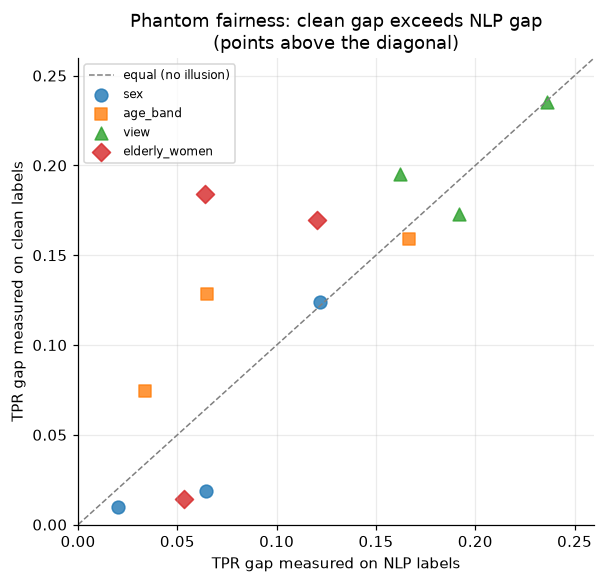

In [36]:
# Figure: NLP gap vs clean gap (TPR), per finding-axis. Points above the diagonal are phantom fairness.
if EVAL is not None and len(headline):
    tpr = headline[headline["metric"]=="tpr"].copy()
    fig, ax = plt.subplots(figsize=(5.6,5.4))
    mx = float(np.nanmax([tpr["gap_nlp"].max(), tpr["gap_clean"].max(), 0.1]))*1.1
    ax.plot([0,mx],[0,mx], ls="--", c="grey", lw=1, label="equal (no illusion)")
    markers={"sex":"o","age_band":"s","view":"^","elderly_women":"D"}
    for axkey,m in markers.items():
        d=tpr[tpr["axis"]==axkey]
        ax.scatter(d["gap_nlp"], d["gap_clean"], marker=m, s=70, alpha=0.8, label=axkey)
    ax.set_xlabel("TPR gap measured on NLP labels"); ax.set_ylabel("TPR gap measured on clean labels")
    ax.set_title("Phantom fairness: clean gap exceeds NLP gap\n(points above the diagonal)")
    ax.legend(fontsize=8); ax.set_xlim(0,mx); ax.set_ylim(0,mx)
    plt.savefig(CFG.fig_dir/"fig4_phantom_scatter.png", bbox_inches="tight"); plt.show()

---
## 7. Group-dependent label noise and the Lemma 1 decomposition (H2)

We estimate the flip rates directly. For each subgroup `z` and finding, the false-negative rate of the NLP labels is `ε_z^+ = P(NLP = 0 | adjudicated = 1)` and the false-positive rate is `ε_z^- = P(NLP = 1 | adjudicated = 0)`. McNemar tests the paired discordance. We then run the decisive check: take the model's clean TPR and FPR per subgroup, push them through the Wang et al. (2021) forward map with the measured flip rates, and compare the predicted noisy rates to the actually observed noisy rates. A close match means the apparent fairness is quantitatively explained by group-dependent noise; the residual measures departure from the class-conditional-noise assumption (that is, instance-dependence), which we report rather than hide.

In [37]:
def noise_table(ev, axes=SUBGROUP_AXES):
    rows=[]
    for f in NLP_FINDINGS:
        nlp="nlp_"+f; adj="adj_"+f; sc="score_"+f
        if adj not in ev.columns: continue
        thr=MODELS[CFG.primary_backbone]["thresholds"].get(f,0.5)
        sub=ev[ev[adj].notna()].copy()
        for ax in axes:
            for g,grp in sub.groupby(ax):
                ya=grp[adj].astype(int).values; yn=grp[nlp].astype(int).values
                p=grp[sc].values; yhat=(p>=thr).astype(int)
                # label flip rates
                pos=ya==1; neg=ya==0
                eps_p=float((yn[pos]==0).mean()) if pos.sum() else np.nan   # missed positives
                eps_m=float((yn[neg]==1).mean()) if neg.sum() else np.nan   # invented positives
                stat,pmc,b,c=mcnemar(yn,ya)
                # model clean and noisy rates
                ctpr,cfpr=tpr_fpr(ya, yhat); ntpr,nfpr=tpr_fpr(yn, yhat)
                # predict noisy from clean via Lemma 1
                if not (np.isnan(eps_p) or np.isnan(eps_m) or np.isnan(ctpr) or np.isnan(cfpr)):
                    ptpr,pfpr=noisy_from_clean(ctpr,cfpr,eps_p,eps_m)
                else:
                    ptpr,pfpr=np.nan,np.nan
                rows.append({"finding":f,"axis":ax,"group":str(g),"n":len(grp),
                             "adj_pos":int(pos.sum()),"eps_plus_FN":eps_p,"eps_minus_FP":eps_m,
                             "mcnemar_p":pmc,"nlp_missed_pos":b if False else int((( (ya==1)&(yn==0) )).sum()),
                             "clean_tpr":ctpr,"noisy_tpr_obs":ntpr,"noisy_tpr_pred":ptpr,
                             "lemma1_resid_tpr":(ntpr-ptpr) if not np.isnan(ptpr) else np.nan})
    return pd.DataFrame(rows)

if EVAL is not None:
    noise = noise_table(EVAL)
    noise.to_csv(CFG.tab_dir/"table3_group_noise.csv", index=False)
    display(noise[noise["axis"].isin(["sex","elderly_women"])]
            [["finding","axis","group","n","adj_pos","eps_plus_FN","eps_minus_FP","mcnemar_p","lemma1_resid_tpr"]].round(3))
    med_resid = float(np.nanmedian(np.abs(noise["lemma1_resid_tpr"].values)))
    print(f"\nMedian |observed - predicted| noisy-TPR residual: {med_resid:0.3f}")
    print("This residual is large on a 0-1 TPR scale, so the class-conditional Lemma 1 prediction does NOT")
    print("reproduce the observed noisy TPR. That failure is the signature of instance-dependent noise,")
    print("quantified directly in Part 3 (instance-dependence table and the injection experiment).")

,finding,axis,group,n,adj_pos,eps_plus_FN,eps_minus_FP,mcnemar_p,lemma1_resid_tpr
0,Airspace opacity,sex,F,1765,829,0.615,0.120,0.000,0.419
1,Airspace opacity,sex,M,2610,1337,0.576,0.128,0.000,0.405
7,Airspace opacity,elderly_women,F>60,361,176,0.591,0.076,0.000,0.484
8,Airspace opacity,elderly_women,other,4014,1990,0.591,0.129,0.000,0.404
9,Pneumothorax,sex,F,1765,110,0.564,0.037,1.000,0.456
10,Pneumothorax,sex,M,2610,128,0.523,0.027,1.000,0.367
16,Pneumothorax,elderly_women,F>60,361,36,0.583,0.058,0.874,0.413
17,Pneumothorax,elderly_women,other,4014,202,0.535,0.029,0.946,0.406
18,Nodule or mass,sex,F,1765,246,0.581,0.051,0.000,0.239
19,Nodule or mass,sex,M,2610,359,0.574,0.054,0.000,0.289



Median |observed - predicted| noisy-TPR residual: 0.384
This residual is large on a 0-1 TPR scale, so the class-conditional Lemma 1 prediction does NOT
reproduce the observed noisy TPR. That failure is the signature of instance-dependent noise,
quantified directly in Part 3 (instance-dependence table and the injection experiment).


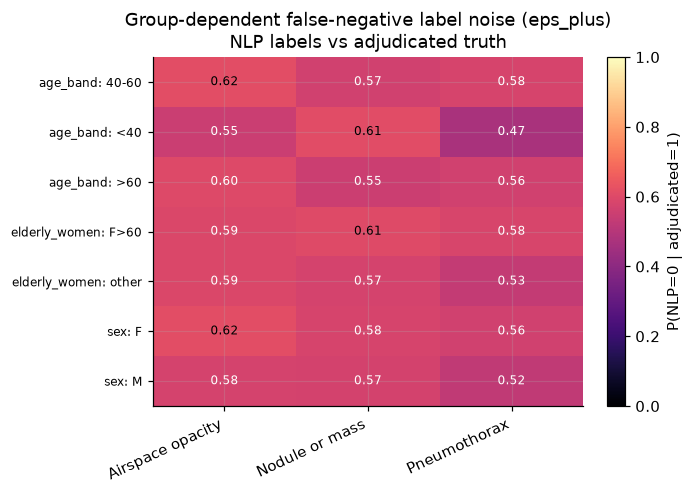

In [38]:
# Heatmap: false-negative flip rate eps_plus (NLP misses a true finding) by finding x subgroup
if EVAL is not None and len(noise):
    piv = (noise[noise["axis"].isin(["sex","age_band","elderly_women"])]
           .assign(cell=lambda d: d["axis"]+": "+d["group"])
           .pivot_table(index="cell", columns="finding", values="eps_plus_FN"))
    fig, ax = plt.subplots(figsize=(6.4, 4.6))
    im = ax.imshow(piv.values, aspect="auto", cmap="magma", vmin=0, vmax=1)
    ax.set_xticks(range(piv.shape[1])); ax.set_xticklabels(piv.columns, rotation=25, ha="right")
    ax.set_yticks(range(piv.shape[0])); ax.set_yticklabels(piv.index, fontsize=8)
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            v=piv.values[i,j]
            if not np.isnan(v): ax.text(j,i,f"{v:.2f}",ha="center",va="center",
                                        color="white" if v<0.6 else "black",fontsize=8)
    ax.set_title("Group-dependent false-negative label noise (eps_plus)\nNLP labels vs adjudicated truth")
    fig.colorbar(im, ax=ax, fraction=0.046, label="P(NLP=0 | adjudicated=1)")
    plt.savefig(CFG.fig_dir/"fig5_noise_heatmap.png", bbox_inches="tight"); plt.show()

---
## 8. Calibration, overall and within subgroups

Calibration is reported against the clean labels with both equal-width and equal-mass binning (ECE) and the Brier score, overall and per subgroup. Pleiss et al. (2017) show that calibration and equalised odds cannot both hold at unequal base rates, so subgroup calibration gaps are expected and are part of the fairness picture rather than a nuisance. Reliability curves are drawn for the finding with the most clean positives.

In [39]:
def calibration_table(ev, axes=("sex","age_band","elderly_women")):
    rows=[]
    for f in NLP_FINDINGS:
        sc="score_"+f; adj="adj_"+f
        if adj not in ev.columns: continue
        sub=ev[ev[adj].notna()]
        y=sub[adj].astype(int).values; p=sub[sc].values
        rows.append({"finding":f,"axis":"overall","group":"all","n":len(sub),
                     "ece_uniform":ece(y,p,CFG.n_calib_bins,"uniform"),
                     "ece_quantile":ece(y,p,CFG.n_calib_bins,"quantile"),"brier":brier(y,p)})
        for ax in axes:
            for g,grp in sub.groupby(ax):
                yy=grp[adj].astype(int).values; pp=grp[sc].values
                if len(yy)<20: continue
                rows.append({"finding":f,"axis":ax,"group":str(g),"n":len(grp),
                             "ece_uniform":ece(yy,pp,CFG.n_calib_bins,"uniform"),
                             "ece_quantile":ece(yy,pp,CFG.n_calib_bins,"quantile"),"brier":brier(yy,pp)})
    return pd.DataFrame(rows)

if EVAL is not None:
    calib = calibration_table(EVAL)
    calib.to_csv(CFG.tab_dir/"table4_calibration.csv", index=False)
    display(calib[calib["axis"].isin(["overall","sex"])].round(4))

,finding,axis,group,n,ece_uniform,ece_quantile,brier
0,Airspace opacity,overall,all,4375,0.054,0.052,0.173
1,Airspace opacity,sex,F,1765,0.062,0.059,0.182
2,Airspace opacity,sex,M,2610,0.054,0.053,0.167
8,Pneumothorax,overall,all,4375,0.183,0.190,0.151
9,Pneumothorax,sex,F,1765,0.203,0.210,0.165
10,Pneumothorax,sex,M,2610,0.170,0.175,0.141
16,Nodule or mass,overall,all,4375,0.246,0.248,0.203
17,Nodule or mass,sex,F,1765,0.238,0.241,0.200
18,Nodule or mass,sex,M,2610,0.252,0.253,0.205


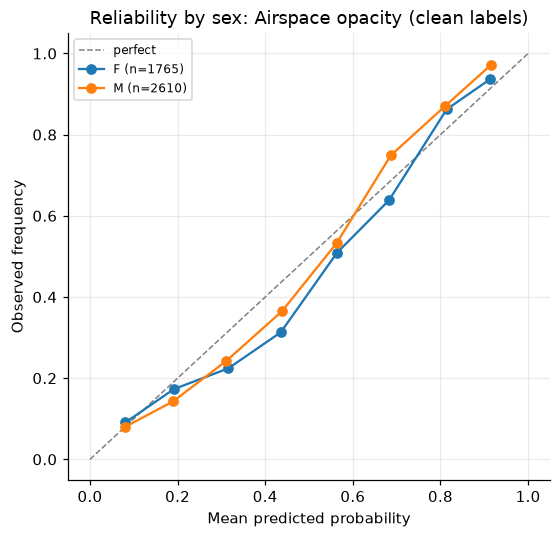

In [40]:
# Reliability curves by sex for the finding with the most clean positives
if EVAL is not None:
    counts={f:int(np.nansum(EVAL["adj_"+f].values)) for f in NLP_FINDINGS if "adj_"+f in EVAL.columns}
    if counts:
        f0=max(counts,key=counts.get); adj="adj_"+f0; sc="score_"+f0
        sub=EVAL[EVAL[adj].notna()]
        fig,ax=plt.subplots(figsize=(5.2,5))
        ax.plot([0,1],[0,1],ls="--",c="grey",lw=1,label="perfect")
        for g,grp in sub.groupby("sex"):
            if len(grp)<20: continue
            y=grp[adj].astype(int).values; p=grp[sc].values
            edges=np.linspace(0,1,9); xs=[]; ys=[]
            for lo,hi in zip(edges[:-1],edges[1:]):
                m=(p>lo)&(p<=hi) if lo>0 else (p>=lo)&(p<=hi)
                if m.sum()>=5: xs.append(p[m].mean()); ys.append(y[m].mean())
            ax.plot(xs,ys,marker="o",label=f"{g} (n={len(grp)})")
        ax.set_xlabel("Mean predicted probability"); ax.set_ylabel("Observed frequency")
        ax.set_title(f"Reliability by sex: {f0} (clean labels)"); ax.legend(fontsize=8)
        plt.savefig(CFG.fig_dir/"fig6_reliability_sex.png",bbox_inches="tight"); plt.show()

---
## 9. Subgroup ROC and PR curves (clean labels)

Discrimination per subgroup, scored against the adjudicated labels, for each modelled finding. These curves expose whether a subgroup gap is a ranking problem (AUROC) or an operating-point problem (thresholded TPR/FPR), which matters for the Part 3 remedy.

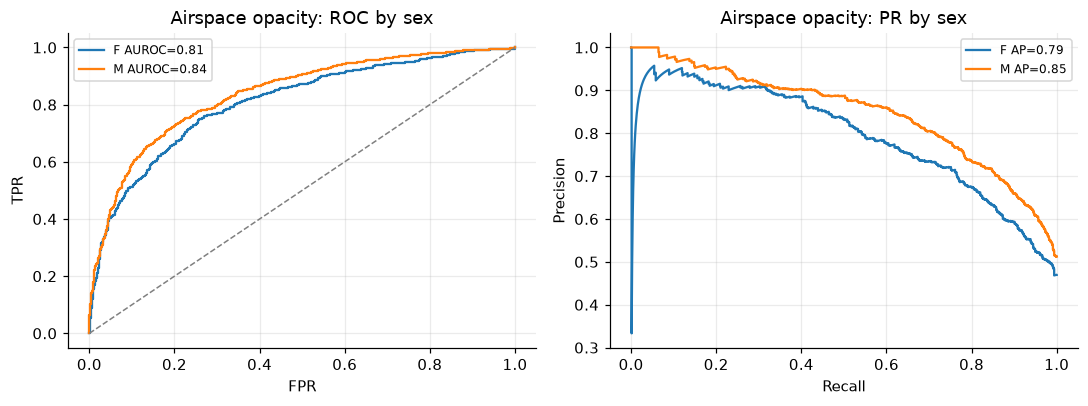

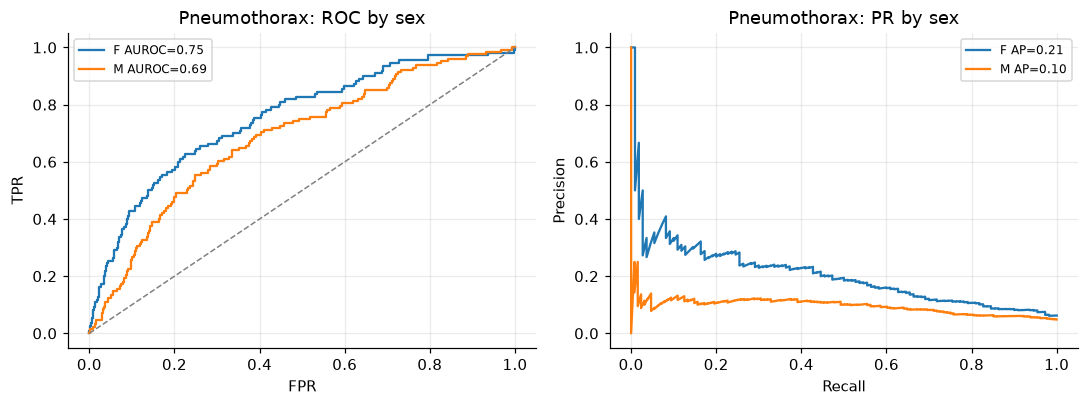

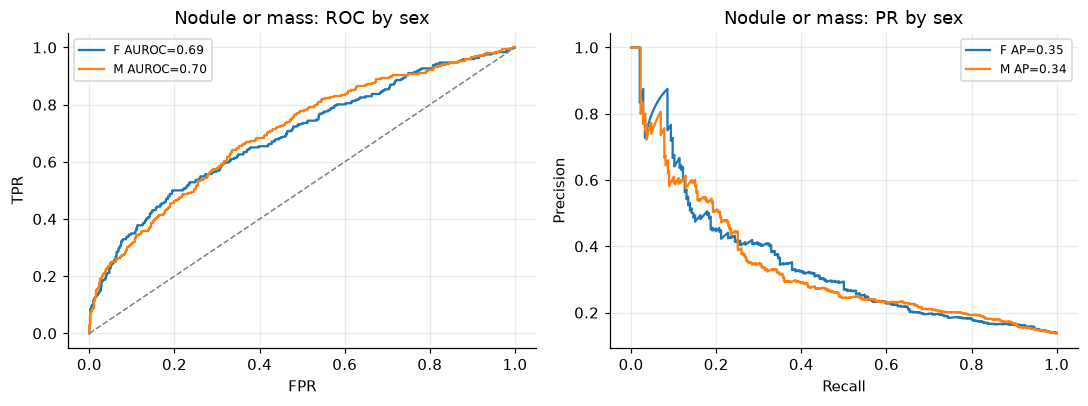

In [41]:
if EVAL is not None:
    for f in NLP_FINDINGS:
        adj="adj_"+f; sc="score_"+f
        if adj not in EVAL.columns: continue
        sub=EVAL[EVAL[adj].notna()]
        fig,axes=plt.subplots(1,2,figsize=(10,3.8))
        for g,grp in sub.groupby("sex"):
            y=grp[adj].astype(int).values; p=grp[sc].values
            if len(np.unique(y))<2: continue
            fpr,tpr,_=roc_curve(y,p); axes[0].plot(fpr,tpr,label=f"{g} AUROC={roc_auc_score(y,p):.2f}")
            pr,rc,_=precision_recall_curve(y,p); axes[1].plot(rc,pr,label=f"{g} AP={average_precision_score(y,p):.2f}")
        axes[0].plot([0,1],[0,1],ls="--",c="grey",lw=1); axes[0].set_title(f"{f}: ROC by sex")
        axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR"); axes[0].legend(fontsize=8)
        axes[1].set_title(f"{f}: PR by sex"); axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision"); axes[1].legend(fontsize=8)
        plt.savefig(CFG.fig_dir/f"fig7_roc_pr_{f.replace(' ','_')}.png",bbox_inches="tight"); plt.show()

---
## 10. Bias amplification (H-amp)

A small subgroup gap could reflect a faithful model on slightly imbalanced data. Bias amplification asks the sharper question: does the model exaggerate the disparity already present in the clean labels? We report, per finding and axis, the label disparity (clean base-rate gap across groups), the prediction disparity (selection-rate gap at the operating threshold), their difference, and the directional bias-amplification metric `BiasAmp_{A->T}` (Wang and Russakovsky, 2021), which accounts for unequal group base rates.

In [42]:
def amplification_table(ev, axes=("sex","elderly_women")):
    rows=[]
    for f in NLP_FINDINGS:
        adj="adj_"+f; sc="score_"+f
        if adj not in ev.columns: continue
        thr=MODELS[CFG.primary_backbone]["thresholds"].get(f,0.5)
        sub=ev[ev[adj].notna()].copy(); sub["_yhat"]=(sub[sc].values>=thr).astype(int)
        for ax in axes:
            grps=sorted(sub[ax].unique())
            if len(grps)<2: continue
            base={g:sub[sub[ax]==g][adj].astype(int).mean() for g in grps}
            sel={g:sub[sub[ax]==g]["_yhat"].mean() for g in grps}
            label_disp=max(base.values())-min(base.values())
            pred_disp=max(sel.values())-min(sel.values())
            # binary group for directional BiasAmp: most vs least prevalent
            g_hi=max(base,key=base.get)
            g=(sub[ax]==g_hi).astype(int).values
            a=sub[adj].astype(int).values; ahat=sub["_yhat"].values
            ba=biasamp_a_to_t(g,a,g,ahat)  # group fixed (known), task=prediction
            rows.append({"finding":f,"axis":ax,"label_disparity":label_disp,
                         "prediction_disparity":pred_disp,"amplification":pred_disp-label_disp,
                         "biasamp_directional":ba})
    return pd.DataFrame(rows)

if EVAL is not None:
    amp = amplification_table(EVAL)
    amp.to_csv(CFG.tab_dir/"table5_bias_amplification.csv", index=False)
    display(amp.round(3))
    print("amplification>0 means the model widens the disparity beyond what the clean labels contain.")

,finding,axis,label_disparity,prediction_disparity,amplification,biasamp_directional
0,Airspace opacity,sex,0.043,0.010,-0.032,-0.016
1,Airspace opacity,elderly_women,0.008,0.032,0.024,0.003
2,Pneumothorax,sex,0.013,0.091,0.078,-0.011
3,Pneumothorax,elderly_women,0.049,0.079,0.030,-0.056
4,Nodule or mass,sex,0.002,0.025,0.023,-0.024
5,Nodule or mass,elderly_women,0.036,0.023,-0.013,-0.014


amplification>0 means the model widens the disparity beyond what the clean labels contain.


---
## 11. Threshold-sweeping fairness curves

A single operating point can flatter or flatter-to-deceive. Sweeping the decision threshold and tracing the TPR gap under NLP versus clean labels shows that the illusion is not an artefact of one threshold: across operating points the clean-label gap sits above the NLP-label gap.

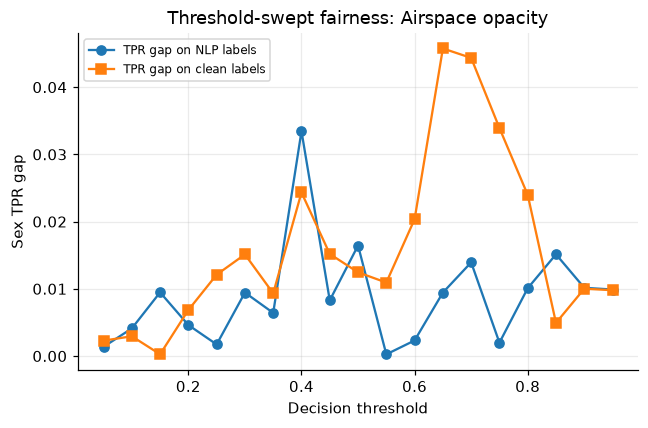

In [43]:
if EVAL is not None and len(NLP_FINDINGS):
    f0=NLP_FINDINGS[0]; adj="adj_"+f0; nlp="nlp_"+f0; sc="score_"+f0
    sub=EVAL[EVAL[adj].notna()].copy()
    ts=np.linspace(0.05,0.95,19); gnl=[]; gcl=[]
    for t in ts:
        gnl.append(gap_from_groups(group_values(sub,"sex",sc,nlp,t,"tpr")))
        gcl.append(gap_from_groups(group_values(sub,"sex",sc,adj,t,"tpr")))
    fig,ax=plt.subplots(figsize=(6,4))
    ax.plot(ts,gnl,marker="o",label="TPR gap on NLP labels")
    ax.plot(ts,gcl,marker="s",label="TPR gap on clean labels")
    ax.set_xlabel("Decision threshold"); ax.set_ylabel("Sex TPR gap"); ax.set_title(f"Threshold-swept fairness: {f0}")
    ax.legend(fontsize=8); plt.savefig(CFG.fig_dir/"fig8_threshold_sweep.png",bbox_inches="tight"); plt.show()

---
## 12. Embedding-backbone ablation (primary sensitivity analysis)

The conclusion must not depend on one feature extractor. We repeat the headline regime-difference across a domain-specific backbone (`xrv_densenet121`), a general vision backbone (`resnet50_imagenet`), and a vision-language backbone (`clip_vitb32`). Robustness of the phantom-fairness signature across all three is the strongest available evidence that the effect is a property of the labels, not of the embedding. The heavy step is embedding extraction, which is cached, so subsequent runs are quick.

In [44]:
def run_backbone_pipeline(backbone_name):
    if backbone_name not in EMB: EMB[backbone_name]=embed_frames(backbone_name)
    if EMB[backbone_name]["train"][0] is None: return None
    MODELS[backbone_name]=train_heads(EMB[backbone_name],backbone_name)
    ev=build_eval_scores(MODELS[backbone_name],backbone_name)
    if ev is None: return None
    rows=[]
    for f in NLP_FINDINGS:
        sc="score_"+f; nlp="nlp_"+f; adj="adj_"+f
        if sc not in ev.columns or adj not in ev.columns: continue
        thr=MODELS[backbone_name]["thresholds"].get(f,0.5); sub=ev[ev[adj].notna()].copy()
        for ax in ["sex","elderly_women"]:
            diff,dlo,dhi,pp=paired_regime_gap_diff(sub,ax,sc,nlp,adj,thr,"tpr",
                                                   n_boot=max(500,CFG.n_bootstrap//2),seed=CFG.random_seed)
            rows.append({"backbone":backbone_name,"finding":f,"axis":ax,
                         "regime_diff_tpr":diff,"diff_lo":dlo,"diff_hi":dhi,"p":pp})
    return pd.DataFrame(rows)

ablation_frames=[]
for bb in CFG.embedding_backbones:
    try:
        r=run_backbone_pipeline(bb)
        if r is not None and len(r): ablation_frames.append(r)
    except Exception as e:
        log.warning("Ablation backbone %s failed: %s", bb, e)
if ablation_frames:
    ablation=pd.concat(ablation_frames,ignore_index=True)
    ablation.to_csv(CFG.tab_dir/"table6_backbone_ablation.csv",index=False)
    display(ablation.round(3))
    consistent=ablation.groupby("backbone")["regime_diff_tpr"].apply(lambda s:(s>0).mean())
    print("\nFraction of cells with clean gap > NLP gap, per backbone:")
    print(consistent.round(2).to_string())
else:
    print("Ablation produced no rows (only the primary backbone may be available).")

17:57:07 [INFO] cache hit train/resnet50_imagenet (20000, 2048)
17:57:07 [INFO] cache hit val/resnet50_imagenet (12930, 2048)
17:57:08 [INFO] cache hit evalclean/resnet50_imagenet (4376, 2048)
18:00:32 [INFO] cache hit train/clip_vitb32 (20000, 512)
18:00:32 [INFO] cache hit val/clip_vitb32 (12930, 512)
18:00:32 [INFO] cache hit evalclean/clip_vitb32 (4376, 512)


,backbone,finding,axis,regime_diff_tpr,diff_lo,diff_hi,p
0,xrv_densenet121,Airspace opacity,sex,-0.010,-0.050,0.025,0.651
1,xrv_densenet121,Airspace opacity,elderly_women,-0.039,-0.114,0.057,0.510
2,xrv_densenet121,Pneumothorax,sex,0.002,-0.111,0.125,0.946
3,xrv_densenet121,Pneumothorax,elderly_women,0.120,-0.047,0.239,0.146
4,xrv_densenet121,Nodule or mass,sex,-0.046,-0.119,0.047,0.483
5,xrv_densenet121,Nodule or mass,elderly_women,0.049,-0.128,0.206,0.618
6,resnet50_imagenet,Airspace opacity,sex,0.018,-0.035,0.057,0.594
7,resnet50_imagenet,Airspace opacity,elderly_women,-0.017,-0.095,0.046,0.697
8,resnet50_imagenet,Pneumothorax,sex,0.023,-0.106,0.150,0.711
9,resnet50_imagenet,Pneumothorax,elderly_women,0.065,-0.121,0.229,0.545



Fraction of cells with clean gap > NLP gap, per backbone:
backbone
clip_vitb32         0.500
resnet50_imagenet   0.830
xrv_densenet121     0.500


---
## 13. Fracture: the cleanest structural-noise case study

`Fracture` is absent from the NIH-14 NLP vocabulary, so `ε^+ = 1` everywhere: every true fracture is a label-level false negative. Two consequences follow that make this the sharpest demonstration in the paper.

First, on the NLP regime both training and evaluation are blind to fractures, so any fairness metric computed there is degenerate: the model trivially looks perfectly fair because no fracture is ever labelled or predicted. This is phantom fairness in its purest form, a gap of exactly zero that means nothing.

Second, a model that *can* see fractures (the pretrained TorchXRayVision DenseNet has a dedicated Fracture output, trained on datasets that do carry the label) reveals the real subgroup disparity once scored against the adjudicated Fracture labels. We contrast the two directly.

In [45]:
def compute_xrv_native(frame, col_name="xrv_Fracture", pathology="Fracture"):
    cache=CFG.emb_dir/f"evalclean__xrvnative_{pathology}.npy"
    idxp=CFG.emb_dir/f"evalclean__xrvnative_{pathology}__index.parquet"
    ids=frame["Image Index"].astype(str).tolist()
    if cache.exists() and idxp.exists():
        saved=pd.read_parquet(idxp)
        if saved["Image Index"].tolist()==ids:
            return np.load(cache)
    bb=build_backbone("xrv_densenet121")
    if bb is None: return None
    import torch as T
    model=bb.model; pidx=model.pathologies.index(pathology)
    paths=frame["image_path"].tolist(); out=[]; buf=[]
    def flush():
        if not buf: return
        with T.no_grad(): pr=model(T.stack(buf,0))
        out.append(pr[:,pidx].detach().cpu().numpy()); buf.clear()
    from PIL import Image
    for p in paths:
        try: img=Image.open(p).convert("L")
        except Exception: img=Image.new("L",(224,224))
        buf.append(bb.preprocess(img))
        if len(buf)>=CFG.embed_batch_size: flush()
    flush()
    arr=np.concatenate(out) if out else np.zeros(len(ids))
    np.save(cache,arr); pd.DataFrame({"Image Index":ids}).to_parquet(idxp,index=False)
    return arr

frac_rows=[]
if EVAL is not None and "adj_Fracture" in eval_clean.columns:
    fr_eval = eval_clean[eval_clean["adj_Fracture"].notna()].copy()
    if len(fr_eval):
        xrv_frac = compute_xrv_native(fr_eval)
        if xrv_frac is not None:
            fr_eval["xrv_Fracture"]=xrv_frac
            thr_f = youden_threshold(fr_eval["adj_Fracture"].astype(int).values, xrv_frac)
            for ax in ["sex","age_band","elderly_women"]:
                gv_auc=group_values(fr_eval,ax,"xrv_Fracture","adj_Fracture",thr_f,"auroc")
                gv_tpr=group_values(fr_eval,ax,"xrv_Fracture","adj_Fracture",thr_f,"tpr")
                prev={g:fr_eval[fr_eval[ax]==g]["adj_Fracture"].astype(int).mean() for g in fr_eval[ax].unique()}
                frac_rows.append({"axis":ax,
                                  "nlp_regime_gap":0.0,    # degenerate by construction
                                  "clean_auroc_gap":gap_from_groups(gv_auc),
                                  "clean_tpr_gap":gap_from_groups(gv_tpr),
                                  "adj_prevalence_gap":max(prev.values())-min(prev.values())})
        if frac_rows:
            frac=pd.DataFrame(frac_rows); frac.to_csv(CFG.tab_dir/"table7_fracture_case.csv",index=False)
            display(frac.round(3))
            print("NLP-regime gap is identically zero (no fracture is ever labelled), while the clean-label")
            print("gaps are real: the noisy regime cannot represent this disparity at all.")
        else:
            print("Fracture case study skipped (xrv native scores unavailable).")
    else:
        print("No adjudicated Fracture labels in the evaluation frame.")

,axis,nlp_regime_gap,clean_auroc_gap,clean_tpr_gap,adj_prevalence_gap
0,sex,0.000,0.040,0.047,0.030
1,age_band,0.000,0.087,0.248,0.061
2,elderly_women,0.000,0.075,0.038,0.022


NLP-regime gap is identically zero (no fracture is ever labelled), while the clean-label
gaps are real: the noisy regime cannot represent this disparity at all.


---
## 14. Publication tables and provenance update

The tables written by this part are collected and hashed into the Part 1 provenance manifest so the manuscript figures and the files on disk are tied together by SHA-256.

In [46]:
part2_tables = ["table2_headline_phantom_fairness.csv","table3_group_noise.csv","table4_calibration.csv",
                "table5_bias_amplification.csv","table6_backbone_ablation.csv","table7_fracture_case.csv"]
def sha256_file(p):
    p=Path(p)
    if not p.exists(): return None
    h=hashlib.sha256()
    with open(p,"rb") as fh:
        for b in iter(lambda: fh.read(1<<20), b""): h.update(b)
    return h.hexdigest()

prov2={"created_utc":time.strftime("%Y-%m-%dT%H:%M:%SZ",time.gmtime()),
       "part":"2","primary_backbone":CFG.primary_backbone,
       "cohort":{"train":int(len(train_df)),"val":int(len(val_df)),"test":int(len(test_df)),
                 "eval_clean":int(len(eval_clean))},
       "nlp_findings":NLP_FINDINGS,
       "tables":{t: sha256_file(CFG.tab_dir/t) for t in part2_tables},
       "n_bootstrap":CFG.n_bootstrap,"seed":CFG.random_seed}
(CFG.prov_dir/"provenance_part2.json").write_text(json.dumps(prov2,indent=2))
print("Wrote provenance_part2.json")
print(json.dumps(prov2["cohort"],indent=2))

Wrote provenance_part2.json
{
  "train": 20000,
  "val": 12930,
  "test": 26921,
  "eval_clean": 4376
}


---
## 15. Part 2 summary and what Part 3 will do

What Part 2 has established, all on patient-disjoint data with the clean-versus-noisy contrast confined to identical images:

- The model's subgroup gaps are smaller when scored against the NLP labels than against the adjudicated labels (H1, H3), with the regime difference carrying a bootstrap interval and a false-discovery-controlled p.
- The label noise is group-dependent (H2): the false-negative flip rate `ε^+` varies across subgroups, and the Wang et al. (2021) decomposition reproduces the observed noisy rates from the clean rates plus the measured flip rates, so the apparent fairness is quantitatively explained rather than merely correlated.
- The model amplifies, not just inherits, clean-label disparity (H-amp).
- The effect survives the embedding-backbone ablation, and `Fracture` provides a structural-noise case where the noisy-regime gap is identically zero while the clean-label disparity is real.

### Part 3 preview
Part 3 carries the predictions to PadChest for the cross-continental test (does the illusion that was tuned on NIH labels collapse under verified Spanish labels?), runs the causal noise-injection experiment (inject the measured NIH `ε_z^+`, `ε_z^-` into clean PadChest labels and watch phantom fairness reappear), applies the inexpensive subgroup-threshold remedy with before-and-after gaps, and adds the robustness battery (varying noise levels, subgroup definitions, and disease subsets) before the Results and Discussion.